In [8]:
import numpy as np
from mpi4py import MPI
from basix.ufl import element
from dolfinx import mesh, fem, io, plot
from ufl import TrialFunction, TestFunction, dx

import matplotlib.pyplot as plt
import numpy as np
import ufl
from pathlib import Path
from dolfinx.fem.petsc import LinearProblem

from dolfinx import *



### Geometry Source and Boundary Setup

- Discretized domain $\Omega $.
- Function space: Continuous piecewise-linear finite elements $V \subset H^1(\Omega)$.
- Parameters: $D = 1.0$, $\theta = 0.5$, $\Delta t = 0.4$, $t_\text{end} = 40$.
- Constant given velocity field: $\boldsymbol{\beta}(x,y) = (0.5, 0.5)$.

Gaussian source term:
$$
f(x,y) = 10 \exp\!\Big(-\frac{(x-x_0)^2}{2\sigma_x^2}
-\frac{(y-y_0)^2}{2\sigma_y^2}\Big),
$$
with $x_0 = 0.1\,x_\text{lim}$, $y_0 = 0.3\,y_\text{lim}$, $\sigma_x = \sigma_y = 0.02\,x_\text{lim}$.

Boundary condition:
Homogeneous Dirichlet: $u = 0$ on $\partial\Omega$.


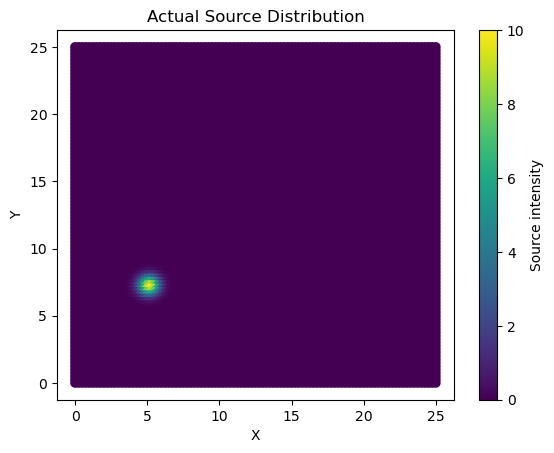

In [ ]:
# Create mesh and define function space
y_lim = 25.0
x_lim = 25.0
nx = 100
ny = 100
domain = mesh.create_rectangle(MPI.COMM_WORLD, ((0,0),(x_lim, y_lim)), [nx, ny])
V = fem.functionspace(domain, element("CG", domain.basix_cell(), 1))

# Parameters
D_phys = fem.Constant(domain, 0.1)
theta = fem.Constant(domain, 0.5)
t_end = 40
dt = 0.4

# Velocity field
def velocity_field(x: np.ndarray):
    return np.full((2, x.shape[1]), 0.5)

V_vec = fem.functionspace(domain, ("CG", 1, (domain.geometry.dim,)))
beta = fem.Function(V_vec)
beta.interpolate(velocity_field)

x0, y0 = 0.2 * x_lim, 0.3 * y_lim
sigma_x, sigma_y = 0.02 * x_lim, 0.02 * y_lim  # Standardabweichung

# Source term as 2D-Gauss
def source_term(x: np.ndarray):
    return 10.0 * np.exp(-((x[0] - x0)**2 / (2 * sigma_x**2) + (x[1] - y0)**2 / (2 * sigma_y**2)))

f_true = fem.Function(V)
f_true.interpolate(source_term)

# Boundary condition (zero dirichlet)
def boundary(x):
    return np.isclose(x[0], 0.0) | np.isclose(x[1], 0.0)
    
u_zero = fem.Constant(domain, 0.0)
bc_zero = fem.dirichletbc(u_zero, fem.locate_dofs_geometrical(V, boundary), V)

x_coords = domain.geometry.x[:, 0]
y_coords = domain.geometry.x[:, 1]
f_values = f_true.x.array

plt.figure()
plt.scatter(x_coords, y_coords, c=f_values, cmap='viridis')
plt.colorbar(label='Source intensity')
plt.title('Actual Source Distribution')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


## Forward PDE Variational Formulation

We consider the stationary advection–diffusion equation:

$$
- D \nabla^2 c + \boldsymbol{\beta} \cdot \nabla c = f,
$$

where:
- $D$ is the diffusion coefficient,
- $\boldsymbol{\beta}$ is the velocity field,
- $f$ is the source term.

### Weak Formulation with SUPG Stabilization

The bilinear and linear forms are:

- **Bilinear form**:
  $$
  a(c,v) =
      D\, (\nabla c, \nabla v)
    + (\boldsymbol{\beta} \cdot \nabla c, v)
    + \tau \, (\boldsymbol{\beta} \cdot \nabla c, \boldsymbol{\beta} \cdot \nabla v)
  $$

- **Linear form**:
  $$
  L(v) =
      (f, v)
    + \tau \, (f, \boldsymbol{\beta} \cdot \nabla v)
  $$

Here, $\tau$ denotes the SUPG stabilization parameter:

$$
\tau = \frac{0.5\,h}{\frac{4}{Pe\,h} + 2\,|\boldsymbol{\beta}|},
$$

where:
- $h$ is the cell diameter,
- $Pe = \frac{|\boldsymbol{\beta}| L}{D}$ is the Péclet number,
- $L$ is the characteristic length.

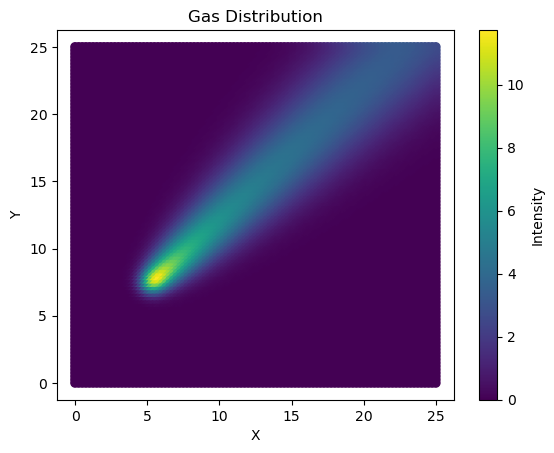

In [10]:
U_char = ufl.sqrt(ufl.dot(beta, beta))
L_char = fem.Constant(domain, x_lim)
h = ufl.CellDiameter(domain)
Pe = U_char * L_char / D_phys
nb = ufl.sqrt(ufl.inner(beta, beta))

tau = 0.5 * h * pow(4.0 / (Pe*h) + 2.0 * nb, -1.0)

v = TestFunction(V)
u = TrialFunction(V)
f = fem.Function(V)

# For true solution: set f to the value of the true source
f = f_true

# a = D_phys * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx + ufl.inner(beta, ufl.grad(u)) * v * dx
# L = f_true * v * dx

# SUPG version
a = D_phys * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx + ufl.inner(beta, ufl.grad(u)) * v * dx + \
         tau * ufl.inner(beta, ufl.grad(u)) * ufl.inner(beta, ufl.grad(v)) * dx
L = f * v * dx + tau * f * ufl.inner(beta, ufl.grad(v)) * dx

forward_problem = LinearProblem(a, L, [bc_zero])

c = forward_problem.solve()
c_values = c.x.array

plt.figure()
plt.scatter(x_coords, y_coords, c=c_values, cmap='viridis')
plt.colorbar(label='Intensity')
plt.title('Gas Distribution')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()



## Inverse Problem Formulation

After the forward problem reaches a steady state ($\frac{\partial c}{\partial t} = 0$), the PDE reads:

$$
\boldsymbol{\beta} \cdot \nabla c - D \nabla^2 c = f,
$$

which can be discretized in FEM form as:

$$
A c = f,
$$

where $A \in \mathbb{R}^{n\times n}$ is the system matrix, and $c, f \in \mathbb{R}^n$.

### Observations and Selection Matrix

We only have measurements $m \in \mathbb{R}^p$ at $p \ll n$ locations.  
Define the selection matrix $M \in \mathbb{R}^{p \times n}$ such that:

$$
M c = m
$$

represents the measured concentration values. Then the inverse problem can be expressed as:

$$
M A^{-1} f = m.
$$

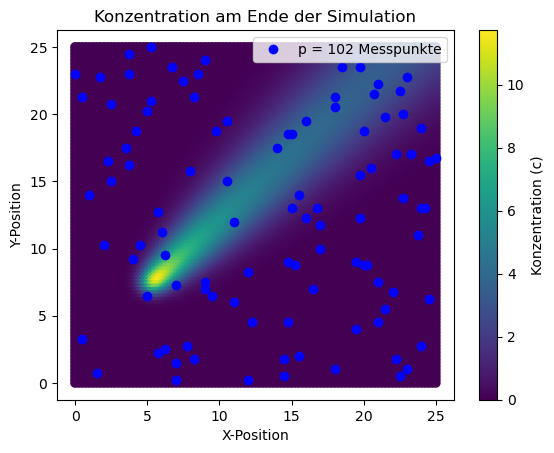

In [ ]:
# Select values from c in m
n = len(c_values)
n_measurements = int(0.01 * n)

# # random distribution
m_ids = np.random.randint(0, n+1, size=n_measurements) # random distribution

# # evenly spaced distribution
# sqrt_points = int(np.sqrt(n_measurements))
# x_plot = np.linspace(0, x_lim, sqrt_points)
# y_plot = np.linspace(0, y_lim, sqrt_points)
# xx_plot, yy_plot = np.meshgrid(x_plot, y_plot)

# measurement_points = np.vstack([xx_plot.flatten(), yy_plot.flatten()]).T
# mesh_coords = domain.geometry.x[:, :2] 

# m_ids = []
# for point in measurement_points:
#     distances = np.linalg.norm(mesh_coords - point, axis=1)
#     closest_node_index = np.argmin(distances)
#     m_ids.append(closest_node_index)

m = c_values[m_ids]

plt.figure()
plt.scatter(x_coords, y_coords, c=c_values, cmap='viridis')
plt.plot(x_coords[m_ids], y_coords[m_ids], 'bo', label=f'p = {n_measurements} Messpunkte')
plt.colorbar(label='Konzentration (c)')
plt.title('Konzentration am Ende der Simulation')
plt.xlabel('X-Position')
plt.ylabel('Y-Position')
plt.legend()
plt.show()




### Minimization Formulation

We formulate an optimization problem to recover $f$ including an L1 regularization term to guarantee a sparse solution:

$$
\begin{aligned}
\min_{f} \quad & J(c,f) = \frac{1}{2} \| M c(f) - m \|_2^2 + \gamma \|f\|_1\\
\text{s.t.} \quad & A c = f,
\end{aligned}
$$

and the associated Lagrangian:

$$
\mathcal{L}(c, f, \lambda) = J(c) + \lambda^\top (A c - f),
$$

where $\lambda$ is the adjoint (Lagrange multiplier) vector. The implicit dependency of $J$ regarding $f$ disappeareds in this step since the constraint is included in $\mathcal{L}$.

---

### KKT Conditions and Weak Form Interpretation


1. **State equation (forward problem)**:
   $$
   \frac{\partial \mathcal{L}}{\partial \lambda} = 0 
   \quad \Rightarrow \quad 
   A c = f
   $$
   Weak form:
   $$
   a(c, v) = L(v) \quad \forall v \in V
   $$

2. **Adjoint equation**:
   $$
   \frac{\partial \mathcal{L}}{\partial c} = 0 
   \quad \Rightarrow \quad 
   A^\top \lambda = - M^\top (M c - m)
   $$
   Weak form:
   $$
   a^*(\lambda, v) := a(v, \lambda) = \int_\Omega D \nabla v \cdot \nabla \lambda 
   + (\boldsymbol{\beta} \cdot \nabla v)\, \lambda \, dx,
   $$
   $$
   L^*(v) := - (M^\top (M c - m), v).
   $$

3. **Gradient with respect to the source $f$ (including L1 regularization)**:
   
   The variation with respect to $f$ only affects the regularization and constraint term of $\mathcal{L}$:

   $$
   \frac{\partial \mathcal{L}}{\partial f} 
   = \gamma\, \frac{\partial \|f\|_1}{\partial f} - \lambda = 0.
   $$

   Subgradient of $|f_i|$:  
   $\partial_{f_i}|f_i| =
   \begin{cases}
   \{+1\}, & f_i>0,\\[-2pt]
   \{-1\}, & f_i<0,\\[-2pt]
   [-1,1], & f_i=0.
   \end{cases}$  


   In practice, we write the gradient compactly as  
   $$
   \nabla_f J = -\lambda + \gamma\, \operatorname{sign}(f),
   $$
   where $\operatorname{sign}(f_i)$ is defined componentwise as above.

Because $\|f\|_1$ is non-differentiable at $f_i=0$, we use a **proximal gradient step** instead of direct gradient descent:

1. Gradient step without regularization:
   $$
   z = f^k + \alpha\, \lambda
   $$
2. Proximal (soft-thresholding) update:
   $$
   f^{k+1}_i = \operatorname{sign}(z_i)\,\max(|z_i| - \alpha \gamma, 0)
   $$
This is done to shrink small values of $f_i$ to zero while keeping the larger entries, enforcing sparsity in the estimated source.

where $\alpha$ is the step size.


In [12]:
# Formulate the adjoint problem with SUPG terms
lagrange_mult = TrialFunction(V)
residual = fem.Function(V)
residual.x.array[:] = 0.0

a_adj = D_phys * ufl.inner(ufl.grad(v), ufl.grad(lagrange_mult)) * dx \
        + ufl.inner(beta, ufl.grad(v)) * lagrange_mult * dx \
        + tau * ufl.inner(beta, ufl.grad(v)) * ufl.inner(beta, ufl.grad(lagrange_mult)) * dx
L_adj = ufl.inner(residual, v) * dx \
        + tau * ufl.inner(beta, ufl.grad(v)) * residual * dx

adjoint_problem = LinearProblem(a_adj, L_adj, [bc_zero])

### Solution Algorithm (Pseudo-code)

1. Initialize $f_0$.
2. **Forward solve**: Find $c \in V$ such that $a(c,v) = L(v)$.
3. **Compute residual**: $r = M c - m$.
4. **Adjoint solve**: Find $\lambda \in V$ such that $a^*(\lambda, v) = L^*(v)$.
5. **Update source**: $f \leftarrow f - \alpha \lambda$.
6. Repeat steps 2–5 until convergence.

In [ ]:
f.x.array[:] = 0.0

max_it = 200
gamma = 1.0
alpha0 = 1.0
tol_rel = 1e-6
tol_grad = 1e-8
c_arm = 1e-3
rho = 0.5
alpha_hist = []
misfit_hist = []

def compute_misfit(c_func: fem.Function, f_func: fem.Function):
    res = c_func.x.array[m_ids] - m
    # return 0.5 * np.dot(res, res) + 0.5 * gamma * np.dot(f_func.x.array, f_func.x.array) # L2
    return np.dot(res, res) + 0.5 * gamma * np.sum(np.abs(f_func.x.array)) # L1

for it in range(max_it):
    # forward
    c = forward_problem.solve()

    # Current misfit
    mis = compute_misfit(c, f)

    # Set adjoint rhs setzen und lösen
    residual.x.array[:] = 0.0
    residual.x.array[m_ids] = -(c.x.array[m_ids] - m)
    adj = adjoint_problem.solve()

    # Gradient
    # gradJ = -adj.x.array + gamma * f.x.array # L2
    gradJ = -adj.x.array # L1 smooth gradient (without regularization term)
    grad_norm = np.linalg.norm(gradJ) 

    alpha = alpha0
    f_old = f.x.array.copy()

    # Armijo search
    while True:
        # L1
        y = f_old - alpha * gradJ
        f.x.array[:] = np.sign(y) * np.maximum(np.abs(y) - alpha * gamma, 0.0)
        # L2
        #f.x.array[:] = f_old - alpha * gradJ
        c_trial = forward_problem.solve()
        mis_trial = compute_misfit(c_trial, f)

        if mis_trial <= mis - c_arm * alpha * grad_norm**2:
            break
        alpha *= rho
    if alpha < 1e-14:
        if grad_norm > tol_grad:
            print("Alpha too small.")
    
    mis_new = compute_misfit(c_trial, f)
    misfit_hist.append(mis_new)
    alpha_hist.append(alpha)

    if it % 10 == 0 or it == max_it-1:
        print(f"it {it:3d} mis={mis:.3e} ||grad||={grad_norm:.3e}")

    # Convergence
    if it > 1:
        rel_change = abs(misfit_hist[-2] - misfit_hist[-1]) / max(1e-12, misfit_hist[-2])
        if rel_change < tol_rel or grad_norm < tol_grad:
            print(f"Stopped at it {it}, rel. change={rel_change:.3e}")
            break

it   0 mis=2.556e+02 ||grad||=3.567e+01
it  10 mis=1.871e+02 ||grad||=2.963e+01
Stopped at it 19, rel. change=4.348e-15


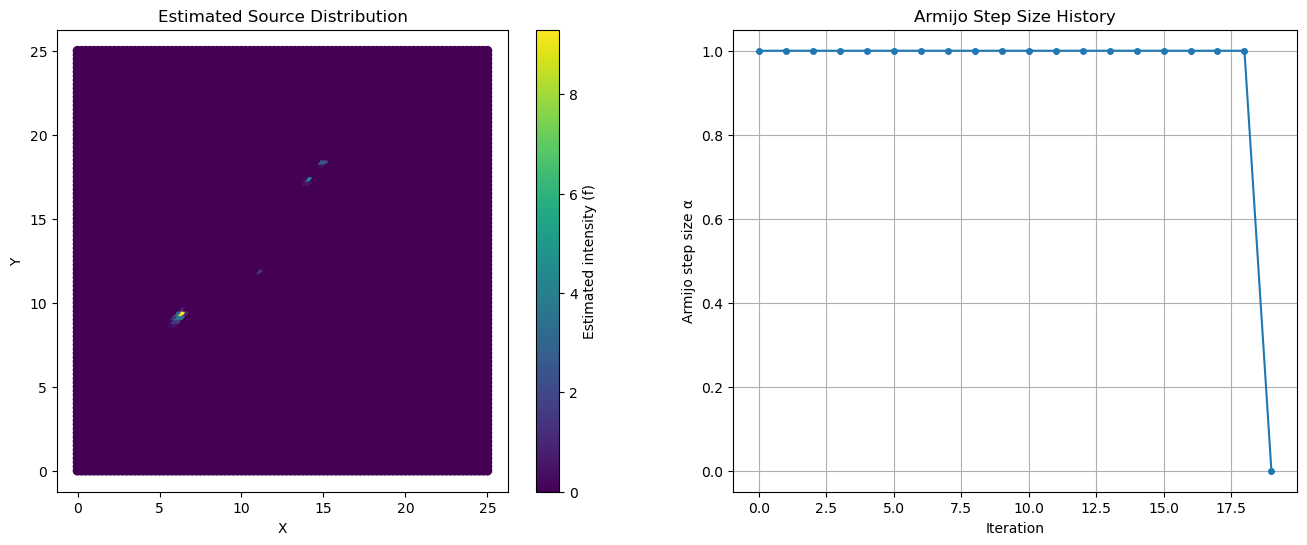

In [14]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.scatter(x_coords, y_coords, c=f.x.array, cmap='viridis')
plt.colorbar(label='Estimated intensity (f)')
plt.title('Estimated Source Distribution')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1,2,2)
plt.plot(range(len(alpha_hist)), alpha_hist, 'o-', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Armijo step size α')
plt.title('Armijo Step Size History')
plt.grid(True)

plt.show()